**Install Libraries**

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.8 MB/s eta 0:00:00


In [3]:
!pip install tensorflow==2.12.0

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 8.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninsta

**Importr Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout,BatchNormalization

**Data Description**

In [2]:
# Load Dataset
data = pd.read_csv("/content/drive/MyDrive/CCF/creditcard.csv")

# Balancing the Dataset
non_fraud = data[data["Class"] == 0]
fraud = data[data["Class"] == 1]

In [3]:
data.shape

(284807, 31)

In [4]:
data['Class'].value_counts()

,count
Class,
0,284315
1,492


In [5]:
fraud.shape

(492, 31)

**Sampling**

In [6]:
# prompt: oversample class 1 on data to 1000 sample

from sklearn.utils import resample

# Upsample minority class
fraud_upsampled = resample(fraud,
                          replace=True,  # sample with replacement
                          n_samples=1000,  # to match majority class
                          random_state=123)  # reproducible results

# Combine majority class with upsampled minority class
data_upsampled = pd.concat([non_fraud[:1000], fraud_upsampled])

# Display new class counts
print(data_upsampled["Class"].value_counts())


Class
0    1000
1    1000
Name: count, dtype: int64


In [7]:
data_upsampled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Data Split**

In [8]:
# Splitting Features & Target
X = data_upsampled.drop(columns="Class", axis=1)
y = data_upsampled["Class"]

In [9]:
# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=30, stratify=y)

In [10]:
print(X_train.shape)

(1600, 30)


In [11]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
150669,93860.0,-10.632375,7.251936,-17.681072,8.204144,-10.166591,-4.510344,-12.981606,6.783589,-4.659330,...,-0.810146,2.715357,0.695603,-1.138122,0.459442,0.386337,0.522438,-1.416604,-0.488307,188.52
243749,152058.0,-3.576362,3.299436,-7.460433,7.783634,-0.398549,-1.968441,-3.110476,-0.328404,-1.574363,...,-0.181455,0.540731,0.719526,0.379249,-0.616962,-0.442811,0.359841,-2.651825,0.422184,1.00
909,685.0,0.874198,-1.153053,0.591410,0.571892,-1.244914,0.182416,-0.582385,0.086637,-0.679556,...,-0.107888,-0.088785,-0.127773,-0.287287,-0.004026,0.457802,-0.241181,0.033369,0.056633,217.00
10897,18690.0,-15.398845,7.472324,-19.026912,11.165526,-6.893856,-2.120937,-14.913330,-0.721214,-7.175097,...,1.111502,-2.444884,0.727495,-0.345078,-0.981749,0.995271,0.816762,2.262942,-1.178063,1.00
123270,76867.0,1.082566,1.094862,-1.367020,2.012554,0.708142,-0.807712,0.151952,0.158353,0.009872,...,-0.135789,-0.325284,-0.734344,-0.106725,-0.224999,0.569167,-0.335033,0.089140,0.112337,1.00


In [12]:
X_test.shape

(400, 30)

In [13]:
X_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
258,181.0,1.136752,-0.103770,0.904686,0.488211,-0.678524,0.039861,-0.581294,0.270996,0.256540,...,-0.166087,-0.017527,-0.093159,0.119723,-0.000588,0.026252,0.229223,0.000201,0.010945,6.47
191267,129186.0,0.290155,0.049243,-0.740524,2.865463,1.395294,-0.535163,0.142543,-0.222770,-1.463691,...,0.247580,0.337349,1.018191,0.303550,0.833886,-1.222306,2.745261,-0.220402,0.168233,7.18
176049,122608.0,-2.003460,-7.159042,-4.050976,1.309580,-2.058102,-0.098621,2.880083,-0.727484,1.460381,...,3.973217,1.244287,-1.015232,-1.800985,0.657586,-0.435617,-0.894509,-0.397557,0.314262,2125.87
95,64.0,-0.658305,0.406791,2.037461,-0.291298,0.147910,-0.350857,0.945373,-0.172560,0.025133,...,0.064133,-0.156096,-0.238805,0.089877,0.421195,-0.352487,0.074783,-0.094192,-0.092493,54.99
6529,7891.0,-1.585505,3.261585,-4.137422,2.357096,-1.405043,-1.879437,-3.513687,1.515607,-1.207166,...,0.315957,0.501543,-0.546869,-0.076584,-0.425550,0.123644,0.321985,0.264028,0.132817,1.00


In [14]:
print(y_train.shape)
print(y_test.shape)

(1600,)
(400,)


**Value Counts**

In [15]:
print(y_train.value_counts())
print(y_test.value_counts())

Class
1    800
0    800
Name: count, dtype: int64
Class
0    200
1    200
Name: count, dtype: int64


**Scaling Data (Standard Scaler)**

In [16]:
# Standardizing the Features (This Boosts CatBoost Performance!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
import joblib

# Save the scaler object
scaler_filename = "/content/drive/MyDrive/CCF/standard_scaler.joblib"
joblib.dump(scaler, scaler_filename)


['/content/drive/MyDrive/CCF/standard_scaler.joblib']

In [19]:
print("Rescaled X_train Data \n==================================\n")
print(X_train)

Rescaled X_train Data 

[[ 9.83016261e-01 -1.68714472e+00  1.61284878e+00 ... -1.68533205e+00
  -1.28554872e+00  4.37914576e-01]
 [ 2.07294356e+00 -2.78770919e-01  4.45814046e-01 ... -3.04805910e+00
   8.66448002e-01 -4.00601730e-01]
 [-7.61957386e-01  6.09556676e-01 -8.68850094e-01 ... -8.56852865e-02
   2.44724869e-03  5.65266029e-01]
 ...
 [ 3.87843066e-01  1.15817394e-01  2.41574495e-01 ...  2.33681504e-01
   1.88304422e-01  3.99816459e-01]
 [-7.70366221e-01  3.47575894e-01 -2.24754066e-01 ...  1.69009679e-01
   1.26845932e-01 -3.73146045e-01]
 [-6.13463734e-01  1.95178746e-03  5.46268433e-01 ...  4.87133045e-01
   5.75187304e-01 -4.00601730e-01]]


In [20]:
print("Sample data of rescaled X_train\n==================================\n")
print(X_train[0])

Sample data of rescaled X_train

[ 0.98301626 -1.68714472  1.61284878 -2.51064626  1.94665521 -2.26703147
 -2.25129747 -1.93661878  1.46398001 -1.58527423 -2.86896124  2.40447149
 -2.95601405  0.46871632 -2.32904394  0.46876082 -2.85753619 -2.1516442
 -1.98600153  2.77863021 -1.03850124  0.9467328   0.72387986 -1.01318076
  0.89281133  0.47329879  1.12059905 -1.68533205 -1.28554872  0.43791458]


In [21]:
X_train[0].shape

(30,)

In [22]:
print("Rescaled X_test Data \n==================================\n")
print(X_test)

Rescaled X_test Data 

[[-0.77139626  0.66196231 -0.55903336 ... -0.1222772  -0.10553907
  -0.37614202]
 [ 1.64459865  0.49298234 -0.51385407 ... -0.36565175  0.26621926
  -0.37296718]
 [ 1.52140641  0.03517894 -2.64220798 ... -0.56109447  0.6113668
   9.1009882 ]
 ...
 [ 1.83039831 -0.49636154 -1.69537546 ... -0.68942475  1.5928665
  -0.30459626]
 [-0.77276339  0.27196235 -0.36658632 ... -0.15415198 -0.16746886
   0.25864773]
 [-0.76935491  0.70555577 -0.91783056 ... -0.11001451 -0.07476839
   0.04655927]]


In [23]:
print("Sample data of rescaled X_test\n==================================\n")
print(X_test[0])

Sample data of rescaled X_test

[-7.71396256e-01  6.61962310e-01 -5.59033360e-01  6.26669274e-01
 -6.27613612e-01  1.71550884e-01  3.93436718e-01  3.45832503e-01
 -6.14023173e-04  6.73392188e-01  6.35942877e-01 -1.65708512e-01
  7.56235572e-01 -7.25941611e-01  8.87438881e-01  8.74555712e-01
  7.61863002e-01  4.58880422e-01  4.82416367e-01 -5.63307357e-01
 -3.98985661e-01 -1.45178177e-01 -2.96050473e-02  1.68573459e-01
  7.56188577e-02 -9.27269162e-02  4.62472613e-01 -1.22277204e-01
 -1.05539075e-01 -3.76142023e-01]


**Machine Learning Model Training : Catboost**

In [24]:
# Initializing CatBoostClassifier
catboost_model = CatBoostClassifier(iterations=100,  # Balanced for speed & accuracy
                                    depth=6,  # Adjust depth based on dataset complexity
                                    learning_rate=0.05,
                                    loss_function='Logloss',
                                    eval_metric='Accuracy',
                                    verbose=10,
                                    random_seed=42)

# Training the Model
catboost_model.fit(X_train, y_train)



0:	learn: 0.9962500	total: 69ms	remaining: 6.83s
10:	learn: 0.9975000	total: 242ms	remaining: 1.96s
20:	learn: 0.9993750	total: 437ms	remaining: 1.65s
30:	learn: 1.0000000	total: 669ms	remaining: 1.49s
40:	learn: 1.0000000	total: 865ms	remaining: 1.24s
50:	learn: 1.0000000	total: 1.02s	remaining: 978ms
60:	learn: 1.0000000	total: 1.13s	remaining: 724ms
70:	learn: 1.0000000	total: 1.33s	remaining: 545ms
80:	learn: 1.0000000	total: 1.52s	remaining: 357ms
90:	learn: 1.0000000	total: 1.72s	remaining: 170ms
99:	learn: 1.0000000	total: 1.9s	remaining: 0us


**Save trained CatBoost model**

In [ ]:


model_filename = "/content/drive/MyDrive/CCF/catboost_model.cbm"
catboost_model.save_model(model_filename)

**Extract Leaf Embeddings (New Features)**

In [ ]:

X_train_leaf = catboost_model.calc_leaf_indexes(X_train)
X_test_leaf = catboost_model.calc_leaf_indexes(X_test)

In [35]:
X_train_leaf

array([[49, 25, 19, ...,  8,  6, 16],
       [ 1, 17, 49, ..., 28, 14, 16],
       [56,  6, 56, ..., 28, 45, 20],
       ...,
       [41,  1, 19, ..., 28, 14, 16],
       [ 8, 38, 48, ..., 28, 13, 28],
       [ 1, 17, 19, ..., 28,  4, 16]], dtype=uint32)

In [36]:
X_test_leaf

array([[14, 38, 48, ..., 24, 13, 20],
       [11,  7, 49, ..., 30, 15, 18],
       [47,  5, 51, ..., 61, 46, 24],
       ...,
       [ 9,  7, 49, ..., 28, 15, 20],
       [40,  6, 48, ..., 26, 13, 30],
       [40, 38, 56, ..., 24, 45, 20]], dtype=uint32)

**Scaling Data : MinMaxSclaer**

In [38]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform X_train_leaf
X_train_scaled = scaler.fit_transform(X_train_leaf)

# Transform X_test_leaf
X_test_scaled = scaler.transform(X_test_leaf)

In [65]:
# prompt: save scaler as min max

# Save the MinMaxScaler object
scaler_filename = "/content/drive/MyDrive/CCF/minmax_scaler.joblib"
joblib.dump(scaler, scaler_filename)


['/content/drive/MyDrive/CCF/minmax_scaler.joblib']

In [62]:
X_train_scaled.shape

(1600, 100)

In [63]:
X_test_scaled.shape

(400, 100)

In [41]:
# X_train = np.expand_dims(X_train_scaled, axis=-1)
# X_test = np.expand_dims(X_test_scaled, axis=-1)

In [42]:
# X_train

array([[[0.79032258],
        [0.40322581],
        [0.29508197],
        ...,
        [0.12903226],
        [0.0952381 ],
        [0.28571429]],

       [[0.01612903],
        [0.27419355],
        [0.78688525],
        ...,
        [0.4516129 ],
        [0.22222222],
        [0.28571429]],

       [[0.90322581],
        [0.09677419],
        [0.90163934],
        ...,
        [0.4516129 ],
        [0.71428571],
        [0.35714286]],

       ...,

       [[0.66129032],
        [0.01612903],
        [0.29508197],
        ...,
        [0.4516129 ],
        [0.22222222],
        [0.28571429]],

       [[0.12903226],
        [0.61290323],
        [0.7704918 ],
        ...,
        [0.4516129 ],
        [0.20634921],
        [0.5       ]],

       [[0.01612903],
        [0.27419355],
        [0.29508197],
        ...,
        [0.4516129 ],
        [0.06349206],
        [0.28571429]]])

**Deep Learning Model Training : CNN**

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

# CNN Model with Batch Normalization
cnn_model = Sequential([
    # First Convolutional Block
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Second Convolutional Block
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Flatten the feature map
    Flatten(),

    # Fully Connected Layers
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu'),
    BatchNormalization(),

    # Output Layer for Binary Classification
    Dense(1, activation='sigmoid')
])

# Compile Model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model Summary
cnn_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 98, 64)            256       
                                                                 
 batch_normalization (BatchN  (None, 98, 64)           256       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 49, 64)           0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 47, 128)           24704     
                                                                 
 batch_normalization_1 (Batc  (None, 47, 128)          512       
 hNormalization)                                                 
                                                        

In [47]:
# Train Model
history=cnn_model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=5, batch_size=16)

Epoch 1/5
100/100 [==============================] - 6s 31ms/step - loss: 0.0848 - accuracy: 0.9737 - val_loss: 0.6655 - val_accuracy: 0.5000
Epoch 2/5
100/100 [==============================] - 2s 18ms/step - loss: 0.0279 - accuracy: 0.9919 - val_loss: 0.4453 - val_accuracy: 0.8925
Epoch 3/5
100/100 [==============================] - 2s 17ms/step - loss: 0.0125 - accuracy: 0.9981 - val_loss: 0.2107 - val_accuracy: 0.9525
Epoch 4/5
100/100 [==============================] - 2s 17ms/step - loss: 0.0295 - accuracy: 0.9906 - val_loss: 0.1070 - val_accuracy: 0.9725
Epoch 5/5
100/100 [==============================] - 2s 17ms/step - loss: 0.0116 - accuracy: 0.9987 - val_loss: 0.0177 - val_accuracy: 0.9975


**Model Evaluation**

In [53]:
# Evaluate the model on the test set
test_loss, test_accuracy = cnn_model.evaluate(X_test_scaled, y_test, batch_size=32, verbose=1)
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')


13/13 [==============================] - 0s 10ms/step - loss: 0.0177 - accuracy: 0.9975
Test Accuracy: 0.9975
Test Loss: 0.0177


**Save Model**

In [54]:
cnn_model.save('/content/drive/MyDrive/CCF/cnn_model_99.h5')

In [55]:
cnn_model.save('/content/drive/MyDrive/CCF/cnn_model_99.keras')

**Metrics Plot**

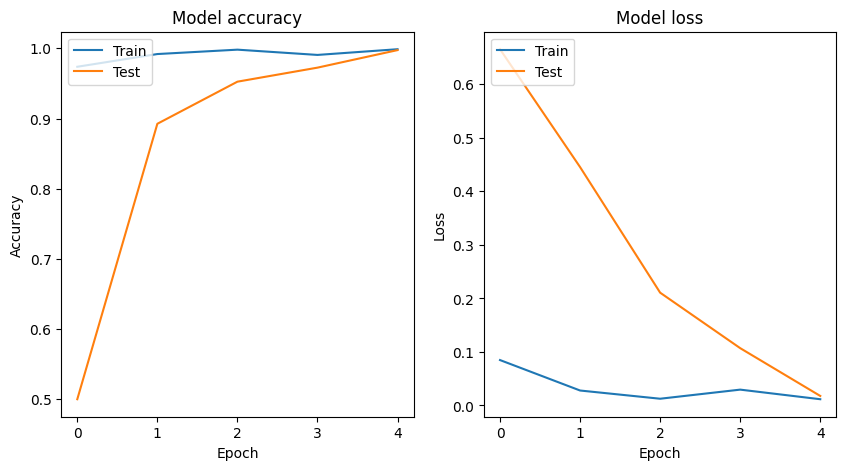

In [56]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


**Classification Report**

In [58]:
from sklearn.metrics import classification_report

# Make predictions on the test set
y_pred_prob = cnn_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary predictions

# Generate classification report
print(classification_report(y_test, y_pred))


13/13 [==============================] - 0s 8ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



**Confusion Matrix**

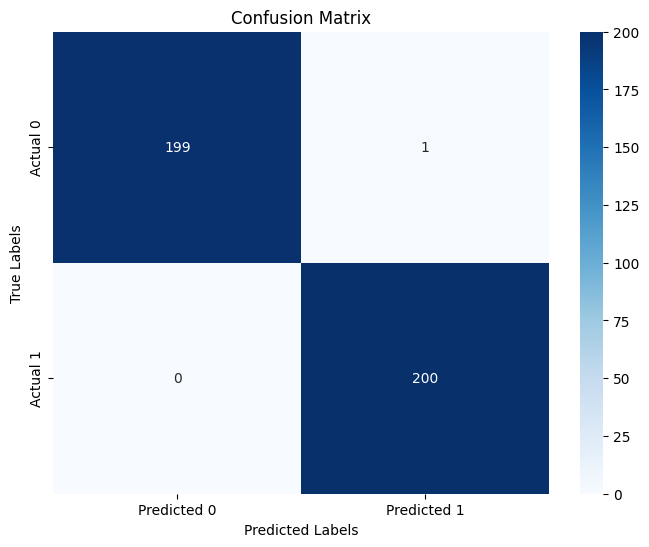

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test and y_pred are already defined from your model's predictions
# Example:
# y_pred = cnn_model.predict(X_test_scaled)
# y_pred = (y_pred > 0.5).astype(int)

conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


# **Prediction**

In [34]:
# prompt: laod sample csv for test and read ,then load scale data and convert rescaling then load catboost then extract calc leaf index
sample_data = pd.read_csv("/content/drive/MyDrive/CCF/Legit.csv")

In [35]:


# Load the saved CatBoost model
import joblib
from catboost import CatBoostClassifier

model_filename = "/content/drive/MyDrive/CCF/catboost_model.cbm"
catboost_model = CatBoostClassifier()
catboost_model.load_model(model_filename)

# Load the saved scaler
scaler_filename = "/content/drive/MyDrive/CCF/standard_scaler.joblib"
standar_scaler = joblib.load(scaler_filename)

# Load sample data (replace with your actual sample data)
X_sample_scaled = standar_scaler.transform(sample_data)


# Extract leaf indices for the sample data
X_sample_leaf = catboost_model.calc_leaf_indexes(X_sample_scaled)

X_sample_leaf


array([[44,  6, 48,  8,  6, 50, 58, 32,  0, 48, 58, 22, 34, 50, 62,  8,
         6, 36, 18, 62, 14, 42, 14,  2, 48, 46, 38, 50, 16, 54,  2,  0,
        34, 50, 48, 16, 18, 38,  0, 24, 34, 48, 34, 44,  2, 56, 56, 38,
        34, 38, 18, 10, 38, 48,  2,  2, 10,  6, 24, 20, 40, 20, 48, 38,
        56, 16, 32, 16, 54, 52, 60, 16, 20,  4, 16, 58, 33, 36,  8, 50,
        55, 20,  4, 48, 24, 18, 44, 56, 38,  2, 60, 44, 40, 24, 52, 48,
        30, 24, 13, 20]], dtype=uint32)

In [36]:

# Load the saved MinMaxScaler
min_max_scaler = joblib.load("/content/drive/MyDrive/CCF/minmax_scaler.joblib")

sample_data_scaled=min_max_scaler.transform(X_sample_leaf)
# Load the saved TF Keras model
cnn_model = tf.keras.models.load_model('/content/drive/MyDrive/CCF/cnn_model_99.h5',compile=False)


# Make predictions
y_pred_prob = cnn_model.predict(sample_data_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Now you can use y_pred for further analysis or evaluation.
if int(y_pred[0][0])==1:
  print("Fraud")
else:
  print("Non Fraud")


1/1 [==============================] - 0s 187ms/step
Non Fraud
